In [ ]:
from datasets import load_dataset
from collections import Counter
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

def add_image(example):
    image_path = f'../data/images/{example["slug"]}.png'
    try:
        img = Image.open(image_path)
        # Convert to RGB if needed (handles RGBA, grayscale, etc.)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        return {"image": img}
    except Exception as e:
        print(f"Error loading image for {example['slug']}: {e}")
        return {"image": None}


def display_image(example):
    plt.figure(figsize=(6, 5))
    plt.imshow(example["image"])
    plt.title(example["slug"])
    plt.axis('off')
    plt.show()
 
def filter_by_topics(example, topics):
    return any(topic in example['topics'] for topic in topics)

dataset = load_dataset('json', data_files='../data/sourceforge_projects.jsonl')

topics_to_remove = [
    "roms", "mobile", "fonts",
    "libraries", "algorithms", "large-language-models-llm" # irrelevant images
    ]


Map: 100%|██████████| 1364/1364 [00:23<00:00, 57.88 examples/s] 


Filter: 100%|██████████| 1364/1364 [00:05<00:00, 262.87 examples/s]


In [ ]:
dataset_cleaned = dataset['train'].filter(lambda x: x['description'] and x['description'].strip() != '' and x['screenshots'] and len(x['screenshots']) > 0)
dataset_cleaned = dataset_cleaned.filter(lambda x: not filter_by_topics(x, topics_to_remove))

# Add image and filter
dataset_cleaned = dataset_cleaned.map(add_image)
dataset_cleaned = dataset_cleaned.map(lambda x : {'width': x['image'].size[0], 'height': x['image'].size[1] })
dataset_cleaned = dataset_cleaned.filter(lambda x: x['width'] > 256 and x['width'] < 1920 and x['height'] > 256 and x['height'] < 1920)



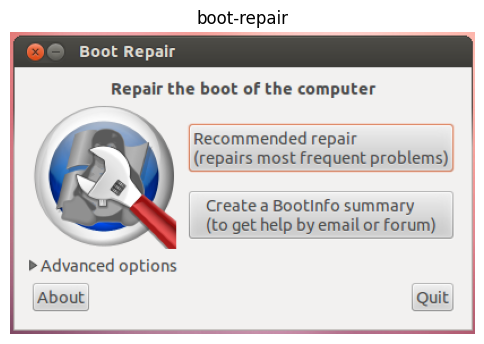

In [12]:
display_image(dataset_cleaned[0])

In [11]:
# Get all unique topics
all_topics = set()
for row in dataset_cleaned:
    if row['topics']:
        all_topics.update(row['topics'])
unique_topics = sorted(list(all_topics))

dataset_cleaned

Dataset({
    features: ['slug', 'url', 'title', 'registration_date', 'description', 'is_mirror', 'screenshots', 'topics', 'image', 'width', 'height'],
    num_rows: 1204
})

In [16]:
# Count slugs per topic
topic_counts = Counter()
for row in dataset_cleaned:
    if row['topics']:
        for topic in row['topics']:
            topic_counts[topic] += 1

image_size_df = dataset_cleaned.select_columns(['slug', 'width', 'height', 'registration_date']).to_pandas()\
    .assign(ratio = lambda x : x['width']/x['height'])
topics_df = pd.DataFrame(topic_counts.items(), columns=['topic', 'count'])

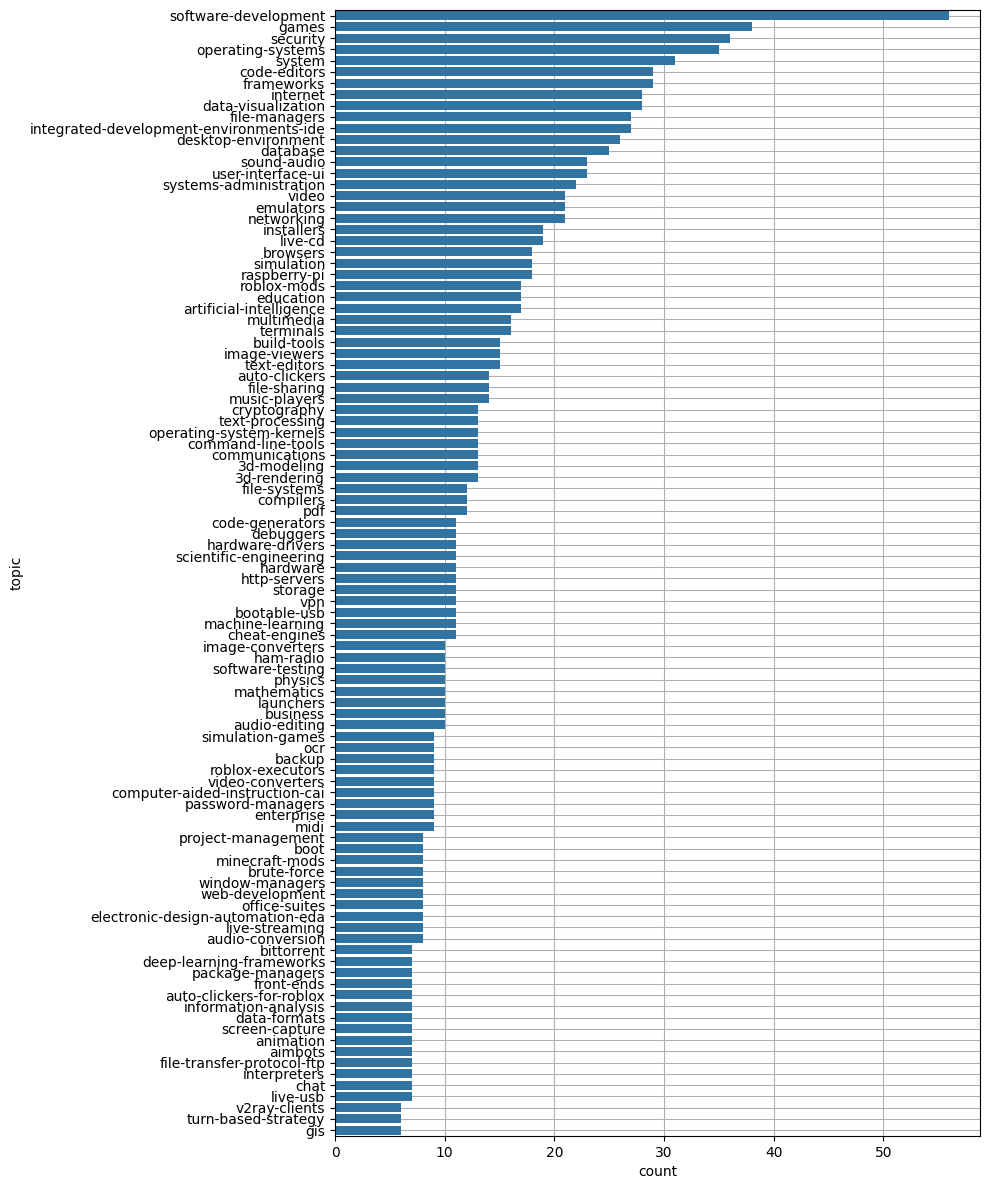

In [17]:
fig, ax= plt.subplots(figsize=(10,12))
N = 100
sns.barplot(topics_df.sort_values("count", ascending=False).head(N), y="topic", x="count", ax=ax)
ax.set_axisbelow(True)
plt.grid()
plt.tight_layout()


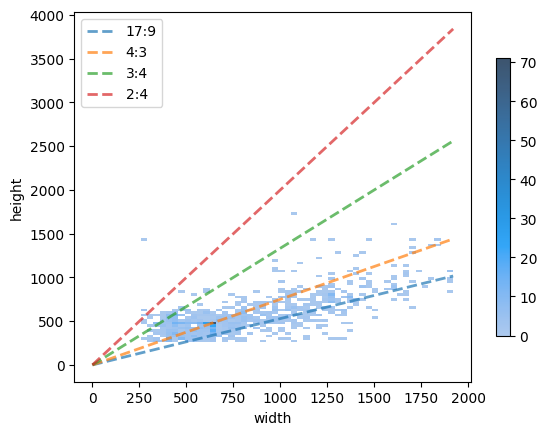

In [18]:
sns.histplot(image_size_df, x="width", y="height", bins=50, cbar=True, cbar_kws=dict(shrink=.75))

max_width = image_size_df["width"].max()
max_height = image_size_df["height"].max()

ratios = {
    "17:9": 17/9,
    "4:3": 4/3,
    "3:4": 3/4,
    "2:4": 2/4,
}

for label, ratio in ratios.items():
    x = np.linspace(0, max_width, 100)
    y = x / ratio
    plt.plot(x, y, linestyle='--', linewidth=2, alpha=0.7, label=label)
plt.legend()


<Axes: xlabel='registration_date', ylabel='ratio'>

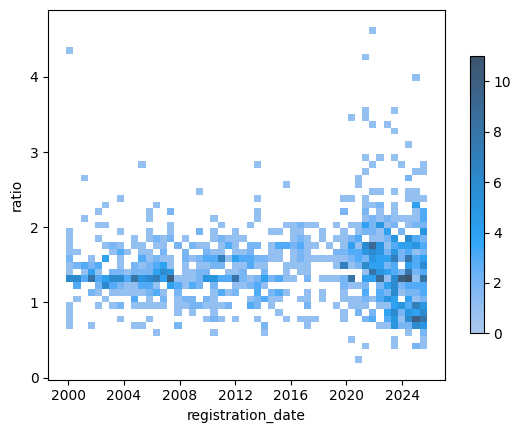

In [19]:
sns.histplot(image_size_df, y="ratio", x="registration_date", bins=50, cbar=True, cbar_kws=dict(shrink=.75))

Text(0.5, 1.0, 'Image Aspect Ratio Distribution')

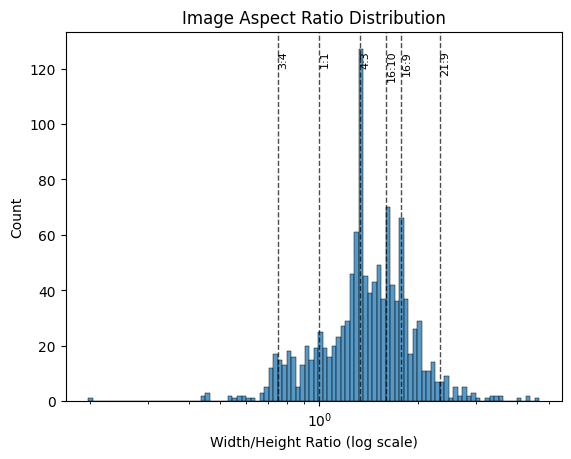

In [20]:
sns.histplot(image_size_df, x="ratio", log_scale=(True, False), bins=100)

typical_ratios = {
    "4:3": 4/3,
    "16:9": 16/9,
    "16:10": 16/10,
    "21:9": 21/9,
    "3:4": 3/4,
    "1:1": 1,
}

for label, ratio in typical_ratios.items():
    plt.axvline(x=ratio, linestyle='--', color='k', alpha=0.7, linewidth=1)
    plt.text(ratio, plt.ylim()[1] * 0.95, label, 
             rotation=90, verticalalignment='top', fontsize=8)

plt.xlabel("Width/Height Ratio (log scale)")
plt.title("Image Aspect Ratio Distribution")

<Axes: xlabel='registration_date', ylabel='Count'>

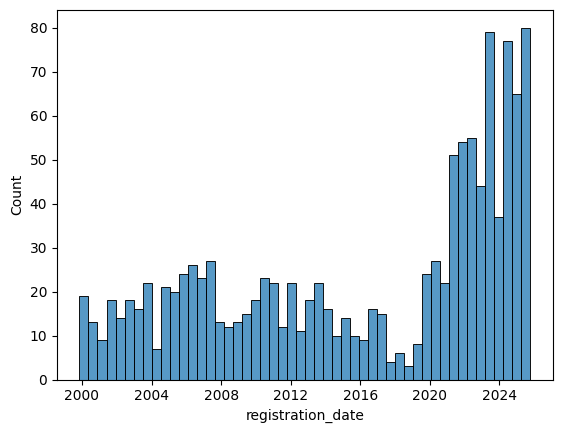

In [22]:
sns.histplot(image_size_df, x="registration_date", bins=50)

In [23]:
slugs_filtered_by_image_size = image_size_df.pipe(lambda x: x[(x["ratio"]>2/4) & (x["ratio"]<17/9)])
slugs_filtered_by_image_size

,slug,width,height,registration_date,ratio
0,boot-repair,411,267,2011-08-11,1.539326
1,codeblocks,635,480,2004-12-20,1.322917
2,crystaldiskinfo,1012,952,2023-08-11,1.063025
3,hwinfo,1126,678,2023-10-05,1.660767
4,infrarecorder,905,647,2006-08-18,1.398764
...,...,...,...,...,...
1199,zero-install,457,364,2003-03-15,1.255495
1200,zerotier.mirror,478,576,2021-08-20,0.829861
1201,zint,528,399,2007-06-23,1.323308
1202,zipkin.mirror,1245,770,2021-01-19,1.616883


<Axes: xlabel='width', ylabel='height'>

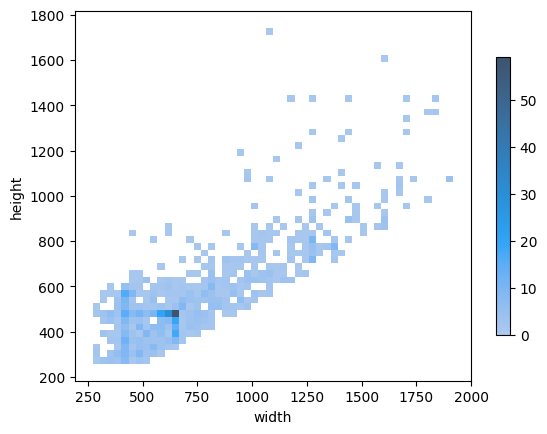

In [24]:
sns.histplot(slugs_filtered_by_image_size, x="width", y="height", bins=50, cbar=True, cbar_kws=dict(shrink=.75))

In [32]:
final_slugs = slugs_filtered_by_image_size["slug"].values
final_dataset = dataset_cleaned.filter(lambda x : x["slug"] in final_slugs).remove_columns(["screenshots"])
final_dataset

Dataset({
    features: ['slug', 'url', 'title', 'registration_date', 'description', 'is_mirror', 'topics', 'image', 'width', 'height'],
    num_rows: 1046
})

In [33]:
final_dataset.push_to_hub("Vokturz/sourceforge-app-screenshots")

Creating parquet from Arrow format: 100%|██████████| 2/2 [00:00<00:00, 14.89ba/s]
Processing Files (1 / 1): 100%|██████████|  134MB /  134MB, 4.49MB/s  
New Data Upload: 100%|██████████|  134MB /  134MB, 4.49MB/s  
Uploading the dataset shards: 100%|██████████| 1/1 [00:30<00:00, 30.94s/ shards]


CommitInfo(commit_url='https://huggingface.co/datasets/Vokturz/sourceforge-app-screenshots/commit/71d474913bc387d1ec3515ca6e3ec95747009192', commit_message='Upload dataset', commit_description='', oid='71d474913bc387d1ec3515ca6e3ec95747009192', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Vokturz/sourceforge-app-screenshots', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Vokturz/sourceforge-app-screenshots'), pr_revision=None, pr_num=None)